### Corelation using Pearson and Spearman Rank

- H₀: ρ = 0 (No correlation between Intentional Death and Economic Gini Index of a country)
- H₁: ρ ≠ 0 (There is a correlation between Intentional Death and Economic Gini Index of a country)

In [31]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/merged_dataset.csv"

df = pd.read_csv(dataset_path)

df

#print(df['intentional_death'].max())
#print(df['intentional_death'].min())

,country_name,country_code,year,suicide_data,homicide_data,intentional_death,gini_index
0,albania,alb,2002,4.48,216.0,220.48,0.32
1,albania,alb,2005,6.91,154.0,160.91,0.31
2,albania,alb,2008,6.95,93.0,99.95,0.30
3,albania,alb,2012,4.09,157.0,161.09,0.29
4,albania,alb,2014,3.80,134.0,137.80,0.35
...,...,...,...,...,...,...,...
1227,vietnam,vnm,2008,7.29,1092.0,1099.29,0.36
1228,vietnam,vnm,2010,7.52,1336.0,1343.52,0.39
1229,zambia,zmb,2010,12.14,814.0,826.14,0.52
1230,zambia,zmb,2015,10.96,853.0,863.96,0.56


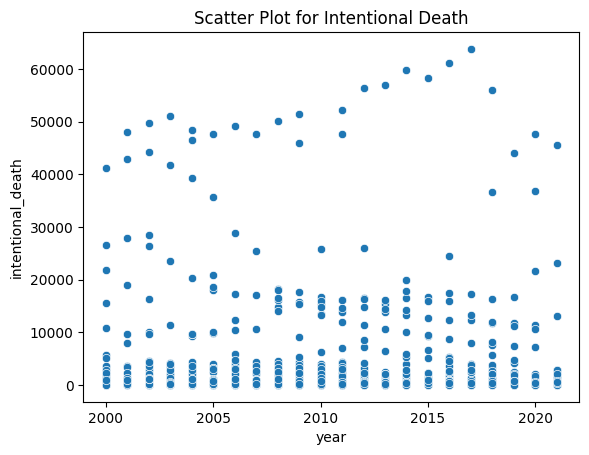

In [ ]:
# Scatter Plot
sns.scatterplot(x=(df['year']), y=df['intentional_death'])
plt.title("Scatter Plot for Intentional Death")
plt.show()

In [26]:
filtered_df = df[(df['intentional_death'] <= 10000)]

filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1120 entries, 0 to 1231
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_name       1120 non-null   object 
 1   country_code       1120 non-null   object 
 2   year               1120 non-null   int64  
 3   suicide_data       1120 non-null   float64
 4   homicide_data      1120 non-null   float64
 5   intentional_death  1120 non-null   float64
 6   gini_index         1120 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 70.0+ KB


### Pearson Correlation

In [ ]:
from scipy.stats import pearsonr
import numpy as np


correlation_matrix = filtered_df.corr(numeric_only=True)
print(correlation_matrix)

# Calculate correlation coefficient and p-value
corr_coefficient, p_value = pearsonr(filtered_df['intentional_death'], filtered_df['gini_index'])
print(f"Pearson Correlation Coefficient: {corr_coefficient}")
print(f"P-value: {p_value}")

                       year  suicide_data  homicide_data  intentional_death  \
year               1.000000     -0.090265      -0.129789          -0.130217   
suicide_data      -0.090265      1.000000      -0.118258          -0.114250   
homicide_data     -0.129789     -0.118258       1.000000           0.999992   
intentional_death -0.130217     -0.114250       0.999992           1.000000   
gini_index        -0.158476     -0.305286       0.349798           0.348723   

                   gini_index  
year                -0.158476  
suicide_data        -0.305286  
homicide_data        0.349798  
intentional_death    0.348723  
gini_index           1.000000  
Pearson Correlation Coefficient: 0.3487231218853638
P-value: 2.2606580155201972e-33


### Spearman Corelation

In [32]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute Spearman correlation
spearman_corr = numeric_df.corr(method='spearman')
print("Spearman Correlation Matrix:")
print(spearman_corr)


Spearman Correlation Matrix:
                       year  suicide_data  homicide_data  intentional_death  \
year               1.000000     -0.040138      -0.176784          -0.179340   
suicide_data      -0.040138      1.000000      -0.100793          -0.082442   
homicide_data     -0.176784     -0.100793       1.000000           0.999550   
intentional_death -0.179340     -0.082442       0.999550           1.000000   
gini_index        -0.120338     -0.377827       0.545895           0.541484   

                   gini_index  
year                -0.120338  
suicide_data        -0.377827  
homicide_data        0.545895  
intentional_death    0.541484  
gini_index           1.000000  


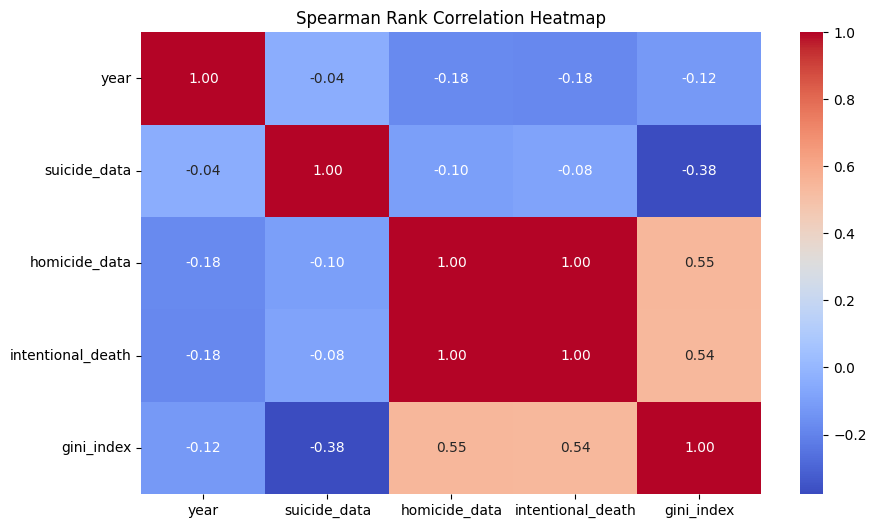

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Rank Correlation Heatmap")
plt.show()


In [34]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(df['intentional_death'], df['gini_index'])
print("Spearman correlation:", rho)
print("p-value:", p_value)


Spearman correlation: 0.5414843220331865
p-value: 8.666594075959332e-95


### Interpretation (APA Style)

A Spearman rank-order correlation showed a moderate positive association between economic inequality and intentional deaths,
ρ = 0.541, p < .001 (p-value: 8.66 × 10⁻⁹⁵).

Because the p-value is extremely small, we reject the null hypothesis.
There is statistically significant evidence that higher inequality is associated with higher intentional death rates.

In [40]:
import statsmodels.api as sm

X = filtered_df['gini_index']
y = filtered_df['intentional_death']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     154.8
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           2.26e-33
Time:                        12:31:46   Log-Likelihood:                -9732.5
No. Observations:                1120   AIC:                         1.947e+04
Df Residuals:                    1118   BIC:                         1.948e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1654.1678    204.019     -8.108      0.0

In [42]:
X = df[['gini_index', 'suicide_data', 'homicide_data', 'year']]
y = df['intentional_death']

X = sm.add_constant(X)
multi_model = sm.OLS(y, X).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.715e+31
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:33:15   Log-Likelihood:                 28940.
No. Observations:                1232   AIC:                        -5.787e+04
Df Residuals:                    1227   BIC:                        -5.784e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -7.276e-12   1.53e-10     -0.047